In [14]:
!pip install selenium webdriver-manager
import os
import platform
import time
import warnings
from pathlib import Path
import re
from urllib.parse import urljoin, urlparse
import requests
from bs4 import BeautifulSoup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# 결과 저장용 임시 폴더 (이 노트북 옆에 'd009_outputs/' 가 만들어집니다)
OUT_DIR = Path("d009_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("저장 폴더:", OUT_DIR.resolve())

   ---------------------------------------- 0.0/9.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.4 MB 2.8 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.4 MB 3.4 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/9.4 MB 4.4 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.4 MB 4.5 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.4 MB 4.5 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.4 MB 4.7 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.4 MB 4.8 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.4 MB 4.7 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.4 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 9.4/9.4 MB 4.8 MB/s  0:00:02

   -- -------------------------------------  1/14 [websocket-client]
   -- -------------------------------------  1/14 [websocket-client]
   -------- -----------------------

In [36]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

url = "https://ecos.bok.or.kr/#/Short/185665"
driver.get(url)

time.sleep(5)  # 충분히 기다리기

html = driver.page_source
print("페이지 길이:", len(html))
print(html[:1000])
print("환율" in html)  # "환율"이라는 글자가 페이지에 있는지

# 여기서는 드라이버를 안 닫음 - 확인 후 수동으로 닫자

페이지 길이: 352966
<html lang="ko"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1,maximum-scale=1,user-scalable=0"><link rel="apple-touch-icon" sizes="57x57" href="/apple-icon-57x57.png"><link rel="apple-touch-icon" sizes="60x60" href="/apple-icon-60x60.png"><link rel="apple-touch-icon" sizes="72x72" href="/apple-icon-72x72.png"><link rel="apple-touch-icon" sizes="76x76" href="/apple-icon-76x76.png"><link rel="apple-touch-icon" sizes="114x114" href="/apple-icon-114x114.png"><link rel="apple-touch-icon" sizes="120x120" href="/apple-icon-120x120.png"><link rel="apple-touch-icon" sizes="144x144" href="/apple-icon-144x144.png"><link rel="apple-touch-icon" sizes="152x152" href="/apple-icon-152x152.png"><link rel="apple-touch-icon" sizes="180x180" href="/apple-icon-180x180.png"><link rel="icon" type="image/png" sizes="192x192" href="/android-icon-192x192.png"><link rel="icon" type="image/png" sizes="32x32" href="/favicon-32x32.png"><link rel="icon" 

In [38]:
print("페이지 길이:", len(html))
print("원/달러" in html)
print("1,4" in html or "1,5" in html)  # 환율 숫자 있는지 대략 확인

페이지 길이: 352966
True
True


In [39]:
# 페이지 전체에서 "1,4XX.XX" 또는 "1,5XX.XX" 형태의 숫자 패턴 찾기
matches = re.findall(r'1[,.]?\d{3}[,.]?\d{2}', html)
print(matches[:20])

['1990.03', '1,367.20', '1,377.90', '1,382.00', '1,391.00', '1,383.10', '1,387.00', '1,401.40', '1,385.20', '1,388.30', '1,389.50', '1,381.20', '1,389.60', '1,388.00', '1,389.90', '1,381.70', '1,382.00', '1,385.00', '1,390.90', '1,398.40']


In [40]:
# "1,367.20" 문자열을 포함한 태그 찾기
target = soup.find(string=re.compile("1,367"))
print(target)
print(target.parent)  # 이 텍스트를 감싸고 있는 태그
print(target.parent.parent)  # 그 상위 태그

1,367.20
<div class="rg-renderer" style="max-height: 29px; overflow: hidden;">1,367.20</div>
<td class="rg-data-cell ta_r rg-data-readonly-cell" role="gridcell"><div class="rg-renderer" style="max-height: 29px; overflow: hidden;">1,367.20</div></td>


In [41]:
cells = soup.find_all('td', class_='rg-data-cell')
print(f"데이터 셀 개수: {len(cells)}")

for cell in cells[:20]:
    print(cell.get_text(strip=True))

데이터 셀 개수: 250
AYwyhi우리테크
1,367.20
1,377.90
1,382.00
1,391.00
1,383.10
1,387.00
1,401.40
1,385.20
1,388.30
1,389.50
1,381.20
1,389.60
1,388.00
1,389.90
1,381.70
1,382.00
1,385.00
1,390.90
1,398.40


In [42]:
cells = soup.find_all('td', class_='rg-data-cell')
print(f"데이터 셀 개수: {len(cells)}")

values = [cell.get_text(strip=True) for cell in cells]

# 숫자 형태(콤마+소수점)인 것만 필터링
import re
clean_values = [v for v in values if re.match(r'^[\d,]+\.\d+$', v)]

print(f"정제 후 개수: {len(clean_values)}")
print(clean_values[:20])

데이터 셀 개수: 250
정제 후 개수: 244
['1,367.20', '1,377.90', '1,382.00', '1,391.00', '1,383.10', '1,387.00', '1,401.40', '1,385.20', '1,388.30', '1,389.50', '1,381.20', '1,389.60', '1,388.00', '1,389.90', '1,381.70', '1,382.00', '1,385.00', '1,390.90', '1,398.40', '1,398.40']


In [43]:
# 필터링에서 제외된(숫자 형태가 아닌) 값들이 뭔지 확인
excluded = [v for v in values if not re.match(r'^[\d,]+\.\d+$', v)]
print(excluded)

['AYwyhi우리테크', '', '3.1.1.3. 원화의 대미달러, 원화의 대위안/대엔 환율', '원/달러(종가 15:30)', '원', '원자료']


In [44]:
headers = soup.find_all('td', class_=re.compile('header'))
print(f"헤더 개수: {len(headers)}")

header_texts = [h.get_text(strip=True) for h in headers]
print(header_texts[:20])

헤더 개수: 250
['2025/07/24', '2025/07/25', '2025/07/28', '2025/07/29', '2025/07/30', '2025/07/31', '2025/08/01', '2025/08/04', '2025/08/05', '2025/08/06', '2025/08/07', '2025/08/08', '2025/08/11', '2025/08/12', '2025/08/13', '2025/08/14', '2025/08/18', '2025/08/19', '2025/08/20', '2025/08/21']


In [45]:
clean_headers = [h for h in header_texts if re.match(r'^\d{4}/\d{2}/\d{2}$', h)]
print(f"정제 후 헤더 개수: {len(clean_headers)}")
print(clean_headers[:10])

정제 후 헤더 개수: 245
['2025/07/24', '2025/07/25', '2025/07/28', '2025/07/29', '2025/07/30', '2025/07/31', '2025/08/01', '2025/08/04', '2025/08/05', '2025/08/06']


In [46]:
print("헤더 처음 5개:", clean_headers[:5])
print("헤더 마지막 5개:", clean_headers[-5:])
print()
print("값 처음 5개:", clean_values[:5])
print("값 마지막 5개:", clean_values[-5:])

헤더 처음 5개: ['2025/07/24', '2025/07/25', '2025/07/28', '2025/07/29', '2025/07/30']
헤더 마지막 5개: ['2026/07/20', '2026/07/21', '2026/07/22', '2026/07/23', '2026/07/24']

값 처음 5개: ['1,367.20', '1,377.90', '1,382.00', '1,391.00', '1,383.10']
값 마지막 5개: ['1,478.40', '1,473.40', '1,480.10', '1,466.80', '1,466.60']


In [32]:
# 두 리스트를 앞에서부터 하나씩 비교하면서, 처음으로 어긋나는 지점 찾기
for i in range(min(len(clean_headers), len(clean_values))):
    pass  # 그냥 순서만 맞으면 넘어가는 걸로 확인

# 날짜 간격이 이상한 곳 찾기 (평일만이라면 보통 1~3일 간격)
from datetime import datetime
dates = [datetime.strptime(h, '%Y/%m/%d') for h in clean_headers]

for i in range(1, len(dates)):
    gap = (dates[i] - dates[i-1]).days
    if gap > 4:  # 4일 넘게 비면 뭔가 이상함 (주말+공휴일 겹쳐도 보통 3일 이내)
        print(f"이상 구간: {clean_headers[i-1]} → {clean_headers[i]} ({gap}일 차이)")

이상 구간: 2025/10/02 → 2025/10/10 (8일 차이)
이상 구간: 2026/02/13 → 2026/02/19 (6일 차이)


In [33]:
# 날짜와 값을 딕셔너리로 짝지어보면서, 혹시 순서가 밀리는 지점 찾기
# 우선 각 날짜에 해당하는 td를 직접 짝지어서 가져오는 게 더 안전함

rows = soup.find_all('tr')  # 행 단위로 접근
print(f"행 개수: {len(rows)}")

행 개수: 22


In [47]:
rows = soup.find_all('tr')
print(f"행 개수: {len(rows)}")

for i, row in enumerate(rows):
    tds = row.find_all('td')
    print(f"행 {i}: td 개수 = {len(tds)}")

행 개수: 22
행 0: td 개수 = 0
행 1: td 개수 = 1
행 2: td 개수 = 0
행 3: td 개수 = 1
행 4: td 개수 = 1
행 5: td 개수 = 0
행 6: td 개수 = 245
행 7: td 개수 = 0
행 8: td 개수 = 245
행 9: td 개수 = 0
행 10: td 개수 = 4
행 11: td 개수 = 0
행 12: td 개수 = 4
행 13: td 개수 = 0
행 14: td 개수 = 0
행 15: td 개수 = 0
행 16: td 개수 = 0
행 17: td 개수 = 1
행 18: td 개수 = 0
행 19: td 개수 = 0
행 20: td 개수 = 3
행 21: td 개수 = 1


In [50]:
header_row = rows[8]   # 6 → 8로 변경
data_row = rows[6]     # 8 → 6로 변경

header_tds = header_row.find_all('td')
data_tds = data_row.find_all('td')

header_texts = [td.get_text(strip=True) for td in header_tds]
data_texts = [td.get_text(strip=True) for td in data_tds]

print("헤더 처음 5개:", header_texts[:5])
print("데이터 처음 5개:", data_texts[:5])

헤더 처음 5개: ['2025/07/24', '2025/07/25', '2025/07/28', '2025/07/29', '2025/07/30']
데이터 처음 5개: ['1,367.20', '1,377.90', '1,382.00', '1,391.00', '1,383.10']


In [51]:
df_exchange = pd.DataFrame({
    '날짜': header_texts,
    '원달러_종가': data_texts
})

print(df_exchange.shape)
print(df_exchange.head())
print(df_exchange.tail())

(245, 2)
           날짜    원달러_종가
0  2025/07/24  1,367.20
1  2025/07/25  1,377.90
2  2025/07/28  1,382.00
3  2025/07/29  1,391.00
4  2025/07/30  1,383.10
             날짜    원달러_종가
240  2026/07/20  1,478.40
241  2026/07/21  1,473.40
242  2026/07/22  1,480.10
243  2026/07/23  1,466.80
244  2026/07/24  1,466.60


In [52]:
df_exchange.to_csv('exchange_rate.csv', index=False, encoding='utf-8-sig')
print('저장 완료: exchange_rate.csv')

저장 완료: exchange_rate.csv


In [53]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

url = "https://ecos.bok.or.kr/#/Short/2680ee"
driver.get(url)

time.sleep(5)

html_kospi = driver.page_source
print("페이지 길이:", len(html_kospi))
print("KOSPI지수" in html_kospi)

페이지 길이: 352761
True


In [54]:
soup_kospi = BeautifulSoup(html_kospi, 'html.parser')
rows_kospi = soup_kospi.find_all('tr')
print(f"행 개수: {len(rows_kospi)}")

for i, row in enumerate(rows_kospi):
    tds = row.find_all('td')
    print(f"행 {i}: td 개수 = {len(tds)}")

행 개수: 22
행 0: td 개수 = 0
행 1: td 개수 = 1
행 2: td 개수 = 0
행 3: td 개수 = 1
행 4: td 개수 = 1
행 5: td 개수 = 0
행 6: td 개수 = 245
행 7: td 개수 = 0
행 8: td 개수 = 245
행 9: td 개수 = 0
행 10: td 개수 = 4
행 11: td 개수 = 0
행 12: td 개수 = 4
행 13: td 개수 = 0
행 14: td 개수 = 0
행 15: td 개수 = 0
행 16: td 개수 = 0
행 17: td 개수 = 1
행 18: td 개수 = 0
행 19: td 개수 = 0
행 20: td 개수 = 3
행 21: td 개수 = 1


In [55]:
row_a = rows_kospi[6]
row_b = rows_kospi[8]

tds_a = [td.get_text(strip=True) for td in row_a.find_all('td')]
tds_b = [td.get_text(strip=True) for td in row_b.find_all('td')]

print("행6 처음 5개:", tds_a[:5])
print("행8 처음 5개:", tds_b[:5])

행6 처음 5개: ['3,190.45', '3,196.05', '3,209.52', '3,230.57', '3,254.47']
행8 처음 5개: ['2025/07/24', '2025/07/25', '2025/07/28', '2025/07/29', '2025/07/30']


In [56]:
df_kospi = pd.DataFrame({
    '날짜': tds_b,
    '코스피_종가': tds_a
})

print(df_kospi.shape)
print(df_kospi.head())
print(df_kospi.tail())

(245, 2)
           날짜    코스피_종가
0  2025/07/24  3,190.45
1  2025/07/25  3,196.05
2  2025/07/28  3,209.52
3  2025/07/29  3,230.57
4  2025/07/30  3,254.47
             날짜    코스피_종가
240  2026/07/20  6,516.27
241  2026/07/21  6,747.95
242  2026/07/22  6,797.70
243  2026/07/23  7,096.89
244  2026/07/24  6,690.62


In [57]:
df_kospi.to_csv('kospi_index.csv', index=False, encoding='utf-8-sig')
print('저장 완료: kospi_index.csv')

저장 완료: kospi_index.csv


In [58]:
df_exchange = pd.read_csv('exchange_rate.csv')
df_kospi = pd.read_csv('kospi_index.csv')

print(df_exchange.shape)
print(df_kospi.shape)
print(df_exchange.dtypes)
print(df_kospi.dtypes)

(245, 2)
(245, 2)
날짜        str
원달러_종가    str
dtype: object
날짜        str
코스피_종가    str
dtype: object


In [59]:
df_exchange['날짜'] = pd.to_datetime(df_exchange['날짜'], format='%Y/%m/%d')
df_kospi['날짜'] = pd.to_datetime(df_kospi['날짜'], format='%Y/%m/%d')

print(df_exchange.dtypes)
print(df_kospi.dtypes)

날짜        datetime64[us]
원달러_종가               str
dtype: object
날짜        datetime64[us]
코스피_종가               str
dtype: object


In [60]:
df_exchange['원달러_종가'] = df_exchange['원달러_종가'].str.replace(',', '').astype(float)
df_kospi['코스피_종가'] = df_kospi['코스피_종가'].str.replace(',', '').astype(float)

print(df_exchange.head())
print(df_kospi.head())

          날짜  원달러_종가
0 2025-07-24  1367.2
1 2025-07-25  1377.9
2 2025-07-28  1382.0
3 2025-07-29  1391.0
4 2025-07-30  1383.1
          날짜   코스피_종가
0 2025-07-24  3190.45
1 2025-07-25  3196.05
2 2025-07-28  3209.52
3 2025-07-29  3230.57
4 2025-07-30  3254.47


In [61]:
final_market = df_exchange.merge(df_kospi, on='날짜', how='outer')
print(final_market.shape)
print(final_market.head())
print(final_market.isnull().sum())

(245, 3)
          날짜  원달러_종가   코스피_종가
0 2025-07-24  1367.2  3190.45
1 2025-07-25  1377.9  3196.05
2 2025-07-28  1382.0  3209.52
3 2025-07-29  1391.0  3230.57
4 2025-07-30  1383.1  3254.47
날짜        0
원달러_종가    1
코스피_종가    1
dtype: int64


In [62]:
# 결측치가 있는 행 확인
print(final_market[final_market.isnull().any(axis=1)])

            날짜  원달러_종가  코스피_종가
107 2025-12-31     NaN     NaN


In [63]:
final_market = final_market.dropna()
print(final_market.shape)
print(final_market.isnull().sum())

(244, 3)
날짜        0
원달러_종가    0
코스피_종가    0
dtype: int64


2025년 12월 31일은 국내 증시·외환시장 휴장일로, 원/달러 환율과 코스피 지수 모두 값이 존재하지 않아 해당 행을 제거함.

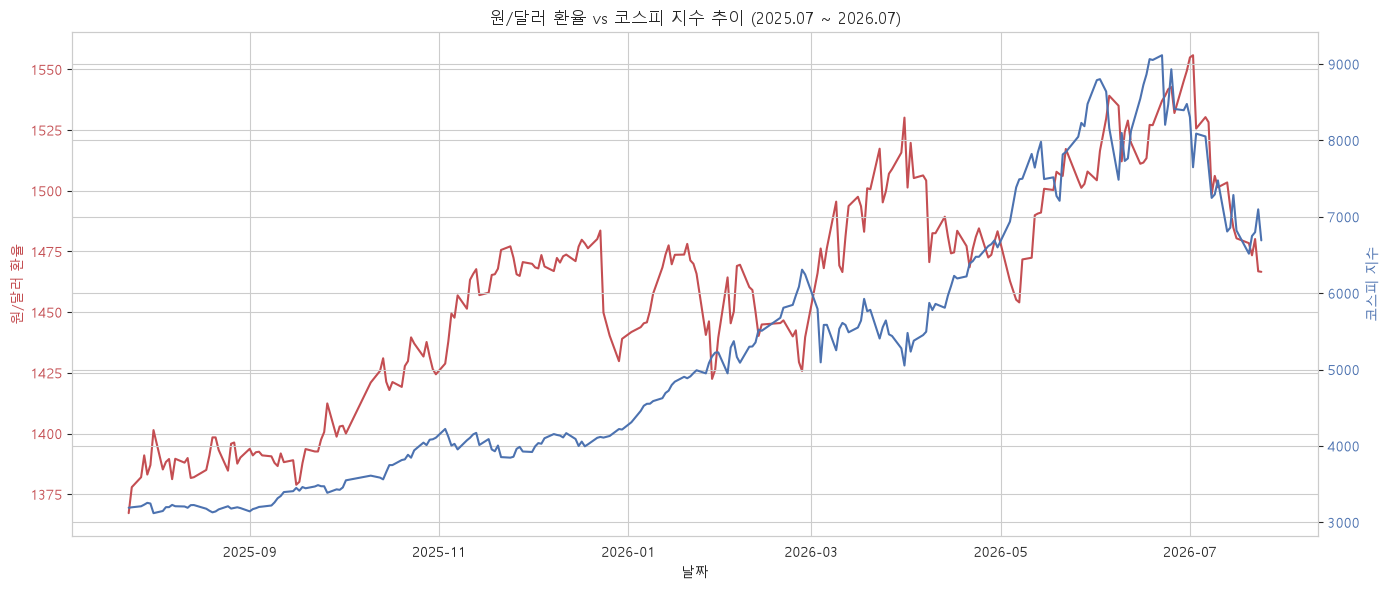

In [64]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(final_market['날짜'], final_market['원달러_종가'], color='#C44E52', label='원/달러 환율')
ax1.set_xlabel('날짜')
ax1.set_ylabel('원/달러 환율', color='#C44E52')
ax1.tick_params(axis='y', labelcolor='#C44E52')

ax2 = ax1.twinx()
ax2.plot(final_market['날짜'], final_market['코스피_종가'], color='#4C72B0', label='코스피 지수')
ax2.set_ylabel('코스피 지수', color='#4C72B0')
ax2.tick_params(axis='y', labelcolor='#4C72B0')

plt.title('원/달러 환율 vs 코스피 지수 추이 (2025.07 ~ 2026.07)')
fig.tight_layout()
plt.show()

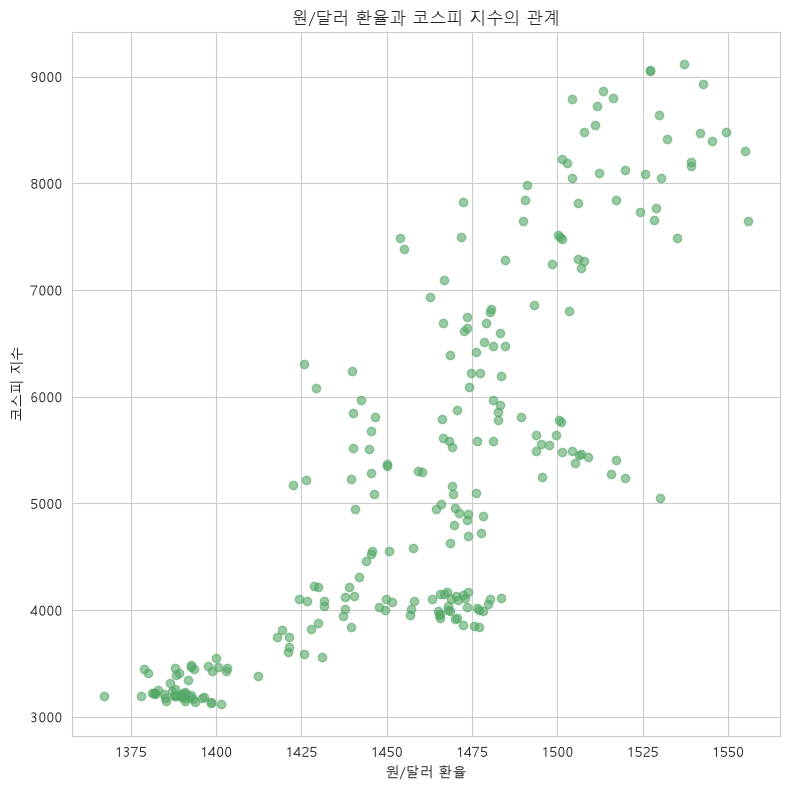

In [65]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(final_market['원달러_종가'], final_market['코스피_종가'], alpha=0.6, color='#55A868')
ax.set_xlabel('원/달러 환율')
ax.set_ylabel('코스피 지수')
ax.set_title('원/달러 환율과 코스피 지수의 관계')

plt.tight_layout()
plt.show()